In [33]:
import pandas as pd
import numpy as np
df = pd.read_csv("teams.csv")
df

,team,group,confederation,host_nation,world_cup_debut,eliminated_round
0,Mexico,A,CONCACAF,Yes,No,NaN
1,South Korea,A,AFC,No,No,Group Stage
2,Czechia,A,UEFA,No,No,Group Stage
3,South Africa,A,CAF,No,No,Group Stage
4,Canada,B,CONCACAF,Yes,No,Round of 16
5,Switzerland,B,UEFA,No,No,NaN
6,Bosnia and Herzegovina,B,UEFA,No,No,Round of 32
7,Qatar,B,AFC,No,No,Group Stage
8,Brazil,C,CONMEBOL,No,No,Round of 16
9,Morocco,C,CAF,No,No,NaN


In [34]:
columns = {"team":"Team",
           	"group":"Group",
            "confederation":"Confederation",
            "host_nation":"Host_Nation",
            "world_cup_debut":"WorldCup_Debut",
            "eliminated_round":"Eliminated_Round"}
df.rename(columns=columns,inplace = True)
df

,Team,Group,Confederation,Host_Nation,WorldCup_Debut,Eliminated_Round
0,Mexico,A,CONCACAF,Yes,No,NaN
1,South Korea,A,AFC,No,No,Group Stage
2,Czechia,A,UEFA,No,No,Group Stage
3,South Africa,A,CAF,No,No,Group Stage
4,Canada,B,CONCACAF,Yes,No,Round of 16
5,Switzerland,B,UEFA,No,No,NaN
6,Bosnia and Herzegovina,B,UEFA,No,No,Round of 32
7,Qatar,B,AFC,No,No,Group Stage
8,Brazil,C,CONMEBOL,No,No,Round of 16
9,Morocco,C,CAF,No,No,NaN


In [35]:
df.shape

(48, 6)

In [36]:
df.isnull().sum()

Team                 0
Group                0
Confederation        0
Host_Nation          0
WorldCup_Debut       0
Eliminated_Round    12
dtype: int64

In [37]:
df.shape

(48, 6)

In [38]:
null_rows = df[df["Eliminated_Round"].isnull()]
print(null_rows.shape)

(12, 6)


In [39]:
df["Eliminated_Round"].fillna("Knockout", inplace=True)

C:\Users\rahul\AppData\Local\Temp\ipykernel_10436\948549485.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Eliminated_Round"].fillna("Knockout", inplace=True)


In [40]:
df

,Team,Group,Confederation,Host_Nation,WorldCup_Debut,Eliminated_Round
0,Mexico,A,CONCACAF,Yes,No,Knockout
1,South Korea,A,AFC,No,No,Group Stage
2,Czechia,A,UEFA,No,No,Group Stage
3,South Africa,A,CAF,No,No,Group Stage
4,Canada,B,CONCACAF,Yes,No,Round of 16
5,Switzerland,B,UEFA,No,No,Knockout
6,Bosnia and Herzegovina,B,UEFA,No,No,Round of 32
7,Qatar,B,AFC,No,No,Group Stage
8,Brazil,C,CONMEBOL,No,No,Round of 16
9,Morocco,C,CAF,No,No,Knockout


In [41]:
df.isnull().sum()

Team                0
Group               0
Confederation       0
Host_Nation         0
WorldCup_Debut      0
Eliminated_Round    0
dtype: int64

In [42]:
df.shape

(48, 6)

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
df.describe()
df.info()
df["Host_Nation"].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Team              48 non-null     object
 1   Group             48 non-null     object
 2   Confederation     48 non-null     object
 3   Host_Nation       48 non-null     object
 4   WorldCup_Debut    48 non-null     object
 5   Eliminated_Round  48 non-null     object
dtypes: object(6)
memory usage: 2.4+ KB


Host_Nation
No     45
Yes     3
Name: count, dtype: int64

<Axes: xlabel='Host_Nation', ylabel='count'>

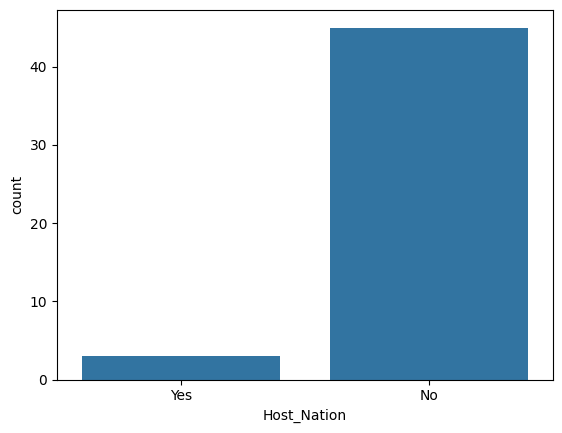

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=df, x='Host_Nation')

In [58]:
df

,Team,Group,Confederation,Host_Nation,WorldCup_Debut,Eliminated_Round
0,Mexico,A,CONCACAF,Yes,No,Knockout
1,South Korea,A,AFC,No,No,Group Stage
2,Czechia,A,UEFA,No,No,Group Stage
3,South Africa,A,CAF,No,No,Group Stage
4,Canada,B,CONCACAF,Yes,No,Round of 16
5,Switzerland,B,UEFA,No,No,Knockout
6,Bosnia and Herzegovina,B,UEFA,No,No,Round of 32
7,Qatar,B,AFC,No,No,Group Stage
8,Brazil,C,CONMEBOL,No,No,Round of 16
9,Morocco,C,CAF,No,No,Knockout


In [59]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["Team","Group","Confederation","Host_Nation","WorldCup_Debut","Eliminated_Round"]:
    df[col] = le.fit_transform(df[col])

In [60]:
df.info

<bound method DataFrame.info of     Team  Group  Confederation  Host_Nation  WorldCup_Debut  Eliminated_Round
0     26      0              2            1               0                 1
1     39      0              0            0               0                 0
2     12      0              5            0               0                 0
3     38      0              1            0               0                 0
4      7      1              2            1               0                 2
5     42      1              5            0               0                 1
6      5      1              5            0               0                 3
7     34      1              0            0               0                 0
8      6      2              3            0               0                 2
9     27      2              1            0               0                 1
10    20      2              2            0               0                 0
11    36      2              5  

In [62]:
y = df['Eliminated_Round']

In [63]:
X = df.drop('Eliminated_Round', axis=1)

In [64]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
print("Training Set :",len(X_train))
print("Testing Set :",len(X_test))

Training Set : 38
Testing Set : 10


In [65]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
predictions = model.predict(X_test)
predictions[:5]

array([3, 1, 3, 0, 3])

In [69]:
from sklearn.metrics import accuracy_score

print("Accuracy_Score :", accuracy_score(y_test, predictions))

Accuracy_Score : 0.2


In [71]:
# Checking 
df.isnull().sum()

Team                0
Group               0
Confederation       0
Host_Nation         0
WorldCup_Debut      0
Eliminated_Round    0
dtype: int64

In [72]:
df.shape

(48, 6)

In [73]:
df.info

<bound method DataFrame.info of     Team  Group  Confederation  Host_Nation  WorldCup_Debut  Eliminated_Round
0     26      0              2            1               0                 1
1     39      0              0            0               0                 0
2     12      0              5            0               0                 0
3     38      0              1            0               0                 0
4      7      1              2            1               0                 2
5     42      1              5            0               0                 1
6      5      1              5            0               0                 3
7     34      1              0            0               0                 0
8      6      2              3            0               0                 2
9     27      2              1            0               0                 1
10    20      2              2            0               0                 0
11    36      2              5  

In [74]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(38, 5)
(10, 5)
(38,)
(10,)


In [75]:
print(predictions[:10])

[3 1 3 0 3 1 0 3 1 3]


In [76]:
comparison = pd.DataFrame({'Actual': y_test,'Predicted': predictions})

print(comparison.head(20))

    Actual  Predicted
27       0          3
40       1          1
26       0          3
43       0          0
24       1          3
37       3          1
12       3          0
19       0          3
4        2          1
25       1          3


In [77]:
print(len(y_test))
print((y_test == predictions).sum())

10
2


In [78]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.2


In [79]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.2
